In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn

## **2. Data Processing**

### **2.1 Carga y Exploración Inicial**
El alumno deberá cargar el dataset, visualizar las primeras filas y explorar la distribución de los datos con histogramas y diagramas de caja.

In [3]:
df = pd.read_csv('Housing.csv')

print("="*50)
print("INFORMACIÓN DEL DATASET")
print("="*50)
print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nÚltimas filas:\n{df.tail()}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:\n{df.describe()}")

INFORMACIÓN DEL DATASET
Forma del dataset: (545, 13)

Primeras filas:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Últimas filas:
       price 

### **2.2 Análisis de Correlación**
Generar una matriz de correlación para analizar relaciones entre variables.

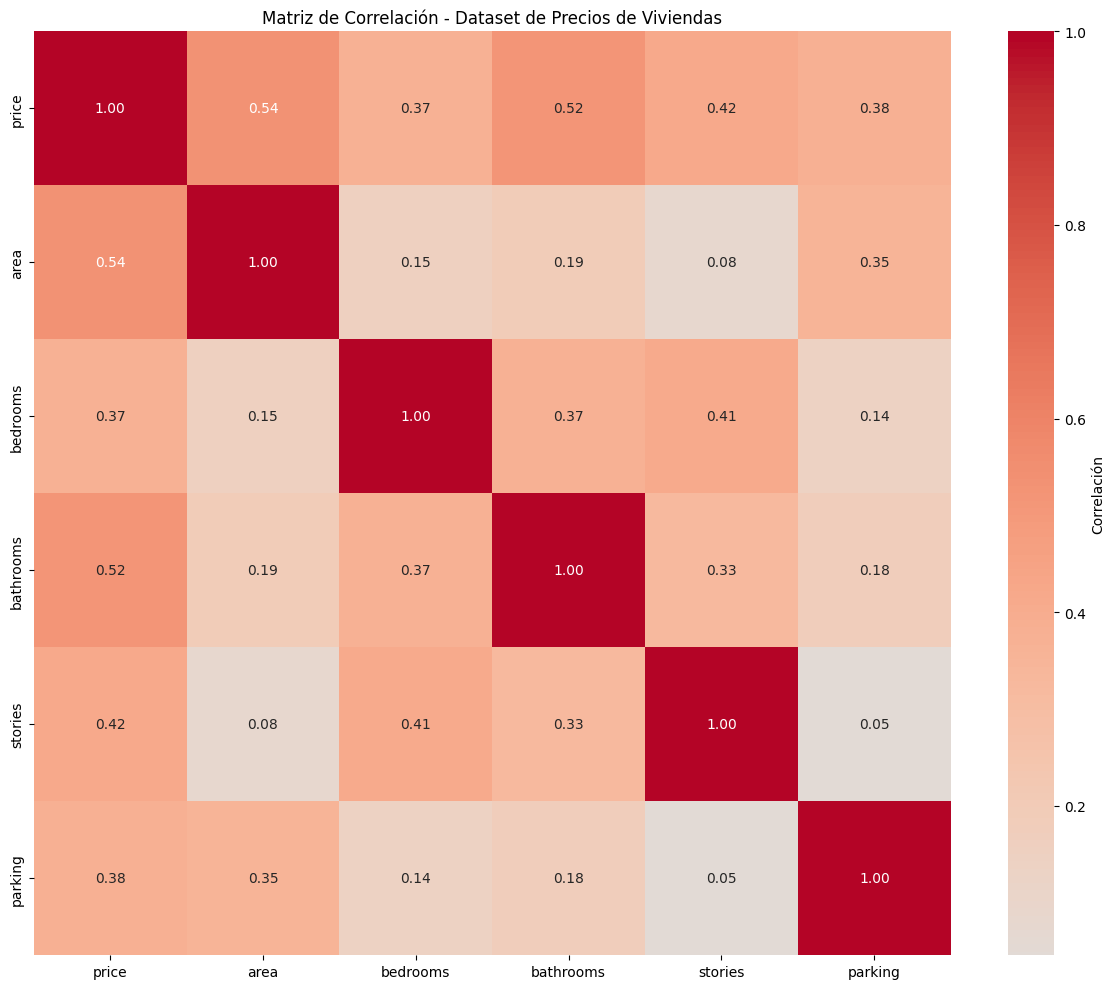

In [5]:
# Obtener solo columnas numéricas
import numpy as np


numeric_df = df.select_dtypes(include=[np.number])

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Dataset de Precios de Viviendas')
plt.tight_layout()
plt.show()

In [6]:
# Mostrar correlación con 'price'
print("\n" + "="*50)
print("CORRELACIÓN CON VARIABLE OBJETIVO 'price'")
print("="*50)
price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)



CORRELACIÓN CON VARIABLE OBJETIVO 'price'
price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


### **2.3 Preprocesamiento de Datos**
Manejo de valores faltantes, codificación de categóricas y normalización.

In [7]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
df['furnishingstatus'].unique()

<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

In [9]:
# Hacer una copia para no modificar el original
df_processed = df.copy()

df_processed['furnishingstatus'] = df_processed['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})
df_processed['mainroad']         = df_processed['mainroad'].map({'yes': 1, 'no': 0})
df_processed['guestroom']        = df_processed['guestroom'].map({'yes': 1, 'no': 0})
df_processed['basement']         = df_processed['basement'].map({'yes': 1, 'no': 0})
df_processed['hotwaterheating']  = df_processed['hotwaterheating'].map({'yes': 1, 'no': 0})
df_processed['airconditioning']  = df_processed['airconditioning'].map({'yes': 1, 'no': 0})
df_processed['prefarea']         = df_processed['prefarea'].map({'yes': 1, 'no': 0})

df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [10]:
from sklearn.preprocessing import StandardScaler

# Separar features y target
X = df_processed.drop(columns=['price'])
y = df_processed['price']

# Crear el scaler y normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir de vuelta a DataFrame (opcional, para verlo mejor)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled.head())

       area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
0  1.046726  1.403419   1.421812  1.378217  0.405623  -0.465315 -0.734539   
1  1.757010  1.403419   5.405809  2.532024  0.405623  -0.465315 -0.734539   
2  2.218232  0.047278   1.421812  0.224410  0.405623  -0.465315  1.361397   
3  1.083624  1.403419   1.421812  0.224410  0.405623  -0.465315  1.361397   
4  1.046726  1.403419  -0.570187  0.224410  0.405623   2.149083  1.361397   

   hotwaterheating  airconditioning   parking  prefarea  furnishingstatus  
0        -0.219265         1.472618  1.517692  1.804941          1.406286  
1        -0.219265         1.472618  2.679409 -0.554035          1.406286  
2        -0.219265        -0.679063  1.517692  1.804941          0.091662  
3        -0.219265         1.472618  2.679409  1.804941          1.406286  
4        -0.219265         1.472618  1.517692 -0.554035          1.406286  


### **2.4 División Train-Test**
División de datos en entrenamiento (80%) y prueba (20%).

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf


# 1. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalizar X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# 3. Normalizar y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

## **3. Model Planning**

### **3.1 Definición del Problema**
- **Tipo de Modelo:** Regresión con red neuronal profunda
- **Entrada:** Variables preprocesadas (características numéricas normalizadas)
- **Salida:** Predicción continua del precio de vivienda
- **Objetivo:** Predecir precios con RMSE < 15% del precio promedio y R² > 0.60

### **3.2 Arquitectura de la Red**
Se utilizará una red neuronal con:
- **Capa de Entrada:** Variables preprocesadas
- **Capas Ocultas:** 
  - Capa 1: 64 neuronas + ReLU + Dropout(0.2) + Regularización L2
  - Capa 2: 32 neuronas + ReLU + Dropout(0.2) + Regularización L2
- **Capa de Salida:** 1 neurona con activación lineal (regresión)

### **3.3 Función de Pérdida y Optimizador**
- **Loss Function:** Error Cuadrático Medio (MSE)
- **Optimizador Primario:** Adam (learning_rate=0.001)
- **Optimizador Alternativo:** SGD con momentum

### **3.4 Evaluación del Modelo**
Se usará K-Fold Cross-Validation (k=5) para evaluar métricas:
- MAE (Error Absoluto Medio)
- RMSE (Raíz del Error Cuadrático Medio)
- R² (Coeficiente de Determinación)

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 4. Definir modelo NUEVO
tf.keras.backend.clear_session()  #  Limpia modelos anteriores

model = keras.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear")
])

# 5. Compilar
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# 6. Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
]

# 7. Entrenar
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0802 - mae: 0.7165 - val_loss: 1.4328 - val_mae: 0.8776
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6771 - mae: 0.5704 - val_loss: 1.0440 - val_mae: 0.7361
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4970 - mae: 0.4962 - val_loss: 0.8198 - val_mae: 0.6478
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3844 - mae: 0.4409 - val_loss: 0.7095 - val_mae: 0.6138
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3370 - mae: 0.4163 - val_loss: 0.6557 - val_mae: 0.6005
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3003 - mae: 0.3969 - val_loss: 0.6595 - val_mae: 0.6032
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2807 - mae: 0.3828 - val_loss: 0.6344 - val_mae: 0.5962
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2725 - mae: 0.3758 - val_loss: 0.6360 - val_mae: 0.5997
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 8. Evaluar
y_pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()
y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2   = r2_score(y_test_real, y_pred_real)

print(f"\nMAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

for real, pred in zip(y_test_real[:5], y_pred_real[:5]):
    print(f"Real: {real:,.0f} → Predicho: {pred:,.0f}")


MAE:  981,055.87
RMSE: 1,284,078.34
R²:   0.6738
Real: 4,060,000 → Predicho: 4,795,216
Real: 6,650,000 → Predicho: 7,912,336
Real: 3,710,000 → Predicho: 3,485,068
Real: 6,440,000 → Predicho: 4,418,234
Real: 2,800,000 → Predicho: 3,653,528


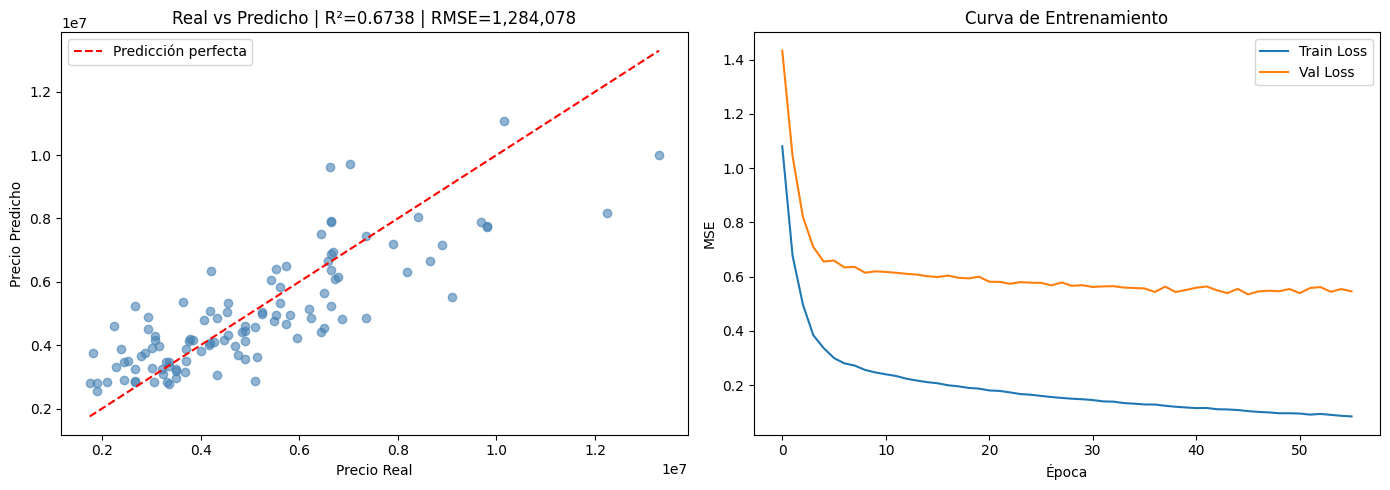

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Real vs Predicho
axes[0].scatter(y_test_real, y_pred_real, alpha=0.6, color='steelblue')
axes[0].plot([y_test_real.min(), y_test_real.max()],
             [y_test_real.min(), y_test_real.max()],
             'r--', label='Predicción perfecta')
axes[0].set_xlabel("Precio Real")
axes[0].set_ylabel("Precio Predicho")
axes[0].set_title(f"Real vs Predicho | R²={r2:.4f} | RMSE={rmse:,.0f}")
axes[0].legend()

# Gráfico 2: Evolución del entrenamiento
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].set_title("Curva de Entrenamiento")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

# Calcular error porcentual de cada predicción
errores = pd.DataFrame({
    'Real':      y_test_real,
    'Predicho':  y_pred_real,
    'Error_abs': np.abs(y_test_real - y_pred_real),
    'Error_%':   np.abs(y_test_real - y_pred_real) / y_test_real * 100
})

# Predicciones con error > 10%
errores_significativos = errores[errores['Error_%'] > 10]

print(f"Predicciones con error > 10%: {len(errores_significativos)} de {len(errores)}")
print(f"Error porcentual medio: {errores['Error_%'].mean():.2f}%")
print(f"\nPeores predicciones:")
print(errores_significativos.sort_values('Error_%', ascending=False).head(5))

Predicciones con error > 10%: 71 de 109
Error porcentual medio: 21.75%

Peores predicciones:
         Real   Predicho  Error_abs     Error_%
79  2233000.0  4607205.0  2374205.0  106.323556
49  1820000.0  3741338.5  1921338.5  105.568049
15  2660000.0  5227264.5  2567264.5   96.513703
18  2940000.0  4876722.5  1936722.5   65.874915
39  2380000.0  3880351.5  1500351.5   63.039979


In [17]:
model.save("modelo_viviendas.keras")